### Contexto

A SeguraAí é uma fintech de venda de seguros para pessoas físicas. Empresas de Seguros, assim como qualquer outra, dependem da recorrência de gastos dos seus clientes. Em Seguros, essa recorrência vem da Renovação das apólices de Seguros dos clientes.

A área de operações pediu um projeto para entender e classificar o cliente com risco de não renovar sua apólice no próximo ano.

Para isso, a área de Operações passou uma base de cerca de 23 mil registros de clientes com suas respectivas informações de cadastro e suas decisões de renovação ou não renovação.

A SeguraAI quer saber:
 1) Quais fatores de risco estão associados com a NÃO renovação de seguros?
 2) Quais os possíveis planos de ação que a empresa de seguros pode fazer para diminuir esse problema?



### Conclusão

A Partir da analises podemos perceber uma Faixa etaria entre 30 e 45 anos são os que mais realizam seguro e os que mais renovam tambem. Homens são os que mais realizam e renovam seguro (comprovado com teste de hipotese). Perfil de risco baixo são os que mais renovam tambem (tambem comprovado com teste), porém quem mais realiza seguro são os de perfil estável 



### Carregamento de pacotes

In [2]:
# Pacotes de preparação dos dados
import pandas as pd
import numpy as np

# Pacotes gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9

#from dtreeviz.trees import dtreeviz

# Pacotes de modelagem
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

# Módulo de Análise Exploratória
import aed
from ydata_profiling import ProfileReport

C:\Users\tania\anaconda3\Lib\site-packages\numba\core\decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
C:\Users\tania\anaconda3\Lib\site-packages\visions\backends\shared\nan_handling.py:50: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.


### Ajuste do banco de dados 

In [3]:
df = pd.read_excel('base_Seguros.xlsx', sheet_name = 1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23060 entries, 0 to 23059
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flag_Renovou       23060 non-null  int64  
 1   Idade              23060 non-null  int64  
 2   Perfil_Risco       23060 non-null  object 
 3   Diferenca_Perfil   23060 non-null  object 
 4   Genero             23060 non-null  object 
 5   Profissao          23060 non-null  object 
 6   Tempo_Apolice      23060 non-null  int64  
 7   Uso_Veiculo        23060 non-null  object 
 8   Qte_Apolices       23060 non-null  int64  
 9   Premio_Final       23060 non-null  float64
 10  Premio_Qte_Parc    23060 non-null  object 
 11  Premio_Pago_Ult    23060 non-null  float64
 12  Premio_Mercado     23060 non-null  float64
 13  Premio_Orig        23060 non-null  float64
 14  Veic_Idade         23060 non-null  int64  
 15  Veic_Idade_Compra  23060 non-null  int64  
 16  Veic_Garagem       230

In [8]:
df["Veic_Garagem"]

0            private garage
1            private garage
2        underground garage
3                    street
4                    street
                ...        
23055    underground garage
23056    underground garage
23057                 other
23058        private garage
23059          parking deck
Name: Veic_Garagem, Length: 23060, dtype: object

### Analise exploratória

Observamos que na pergunta do gestor ele gostaria de informações sobre a não renovação do flag. por default a análise de arvore de decisão avalia a categoria positiva da variável resposta, ou seja, o flag renovou'1' = sim. portanto foi necessário inverter no banco de dados os dados dessa variável. onde era 0 ficou 1 e vice-versa. 

Vimos na análise de IV que nenhuma variável qualitativa teve um gral de separação alto em relação a variável resposta. (essa medida de gral de separação é em relação a variável resposta)

Após a verificação de muitas variáveis altamente correlacionada. como por exemplo: Premio_final, Premio_qte_parc, Premio_pago_ult, Premio_mercado, Premio_orig. decidimos deixar somente a que mais faz sentido para a empresa no momento presente. essa retirada de variáveis também beneficiará a hora em que for feita uma modelagem, pois gerariam muitas variáveis dummies, dificultando a análise.        

### Analise exploratoria 

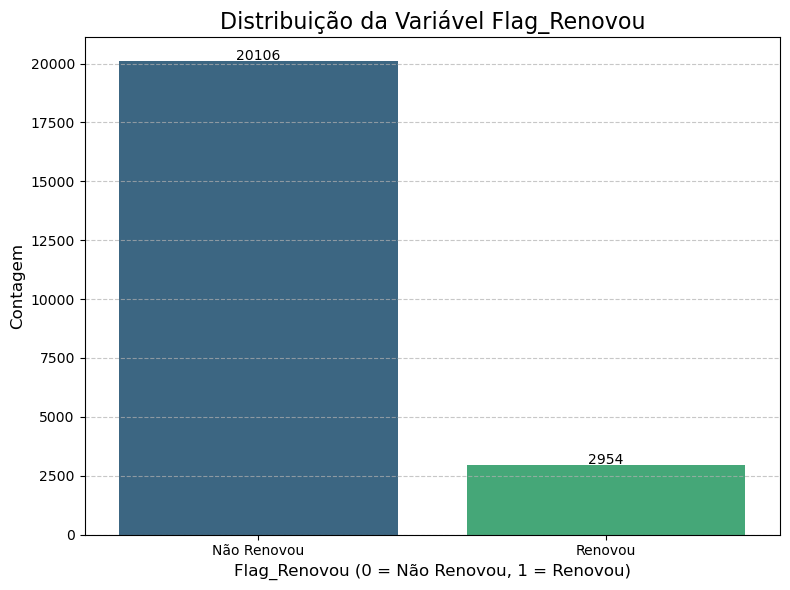

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de valores na variável 'Flag_Renovou'
renovacao_counts = df['Flag_Renovou'].value_counts()

# Plotar gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=renovacao_counts.index, y=renovacao_counts.values, palette='viridis')
plt.title('Distribuição da Variável Flag_Renovou', fontsize=16)
plt.xlabel('Flag_Renovou (0 = Não Renovou, 1 = Renovou)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Não Renovou', 'Renovou'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores exatos em cima das barras
for i, count in enumerate(renovacao_counts.values):
    plt.text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

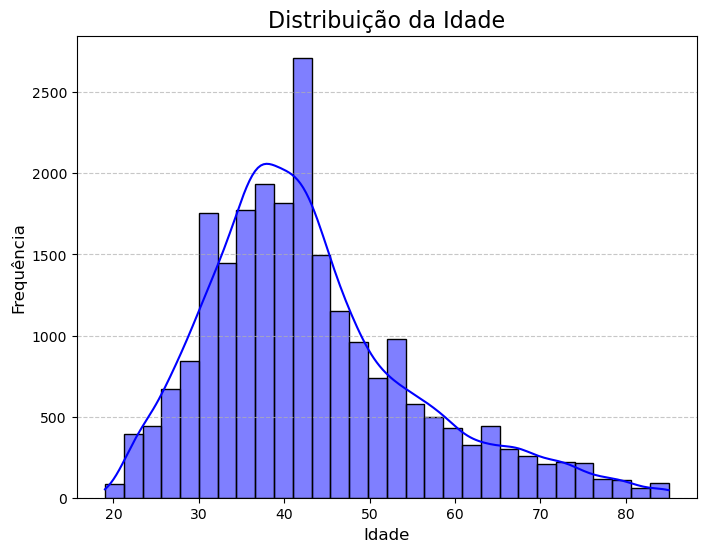

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplo para 'Idade'
plt.figure(figsize=(8, 6))
sns.histplot(df['Idade'], kde=True, bins=30, color='blue')
plt.title('Distribuição da Idade', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
from scipy.stats import chi2_contingency

# Criar uma tabela de contingência para idade e Flag_Renovou
idade_bins = pd.cut(df['Idade'], bins=[0, 30, 44, 60, 100], labels=['<30', '30-44', '45-60', '>60'])
contingency_table_idade = pd.crosstab(idade_bins, df['Flag_Renovou'])

# Teste Chi-Square
chi2, p, _, _ = chi2_contingency(contingency_table_idade)
print(f"Chi-Square: {chi2}, p-value: {p}")

Chi-Square: 89.33430799905096, p-value: 3.044619568153552e-19


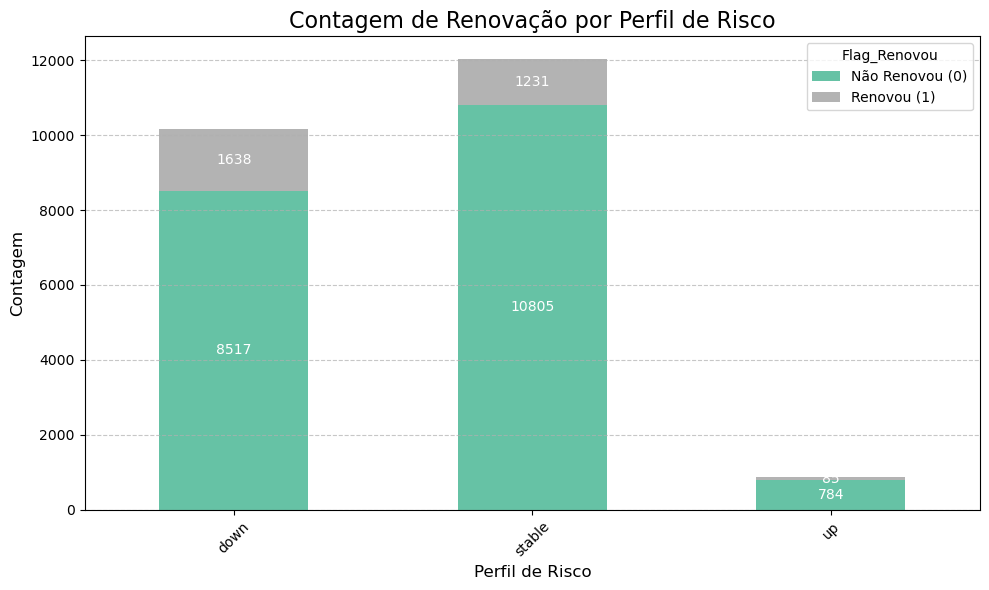

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma tabela de contingência para 'Perfil_Risco' e 'Flag_Renovou'
contingency_table = pd.crosstab(df['Perfil_Risco'], df['Flag_Renovou'])

# Plotar o gráfico de barras empilhadas
ax = contingency_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

# Adicionar os valores exatos em cima das barras
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=10, color='white')

plt.title('Contagem de Renovação por Perfil de Risco', fontsize=16)
plt.xlabel('Perfil de Risco', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Flag_Renovou', labels=['Não Renovou (0)', 'Renovou (1)'])
plt.tight_layout()
plt.show()


In [18]:
from scipy.stats import chi2_contingency

# Criar tabela de contingência
contingency_table = pd.crosstab(df['Perfil_Risco'], df['Flag_Renovou'])

# Aplicar o Teste Chi-Square
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square: {chi2}")
print(f"P-Value: {p}")
print(f"Graus de Liberdade: {dof}")
print("Frequências Esperadas:")
print(expected)

Chi-Square: 179.21339624095398
P-Value: 1.214242598011718e-39
Graus de Liberdade: 2
Frequências Esperadas:
[[ 8854.13833478  1300.86166522]
 [10494.1810928   1541.8189072 ]
 [  757.68057242   111.31942758]]


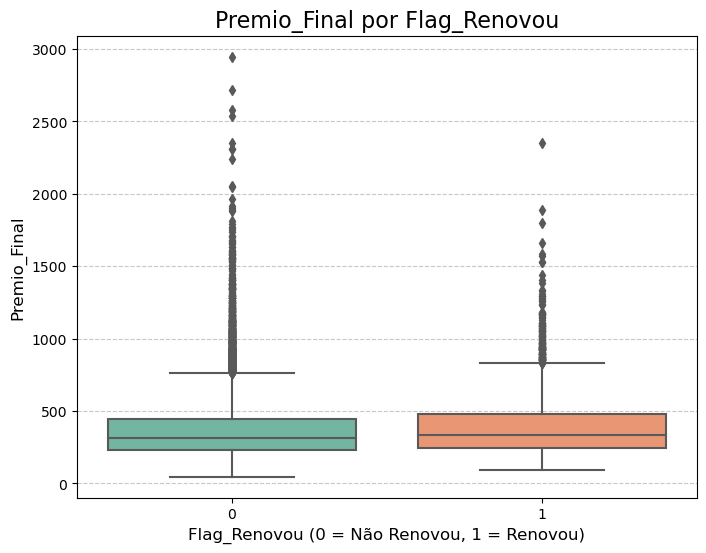

In [6]:
# Exemplo para 'Premio_Final'
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Flag_Renovou', y='Premio_Final', palette='Set2')
plt.title('Premio_Final por Flag_Renovou', fontsize=16)
plt.xlabel('Flag_Renovou (0 = Não Renovou, 1 = Renovou)', fontsize=12)
plt.ylabel('Premio_Final', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

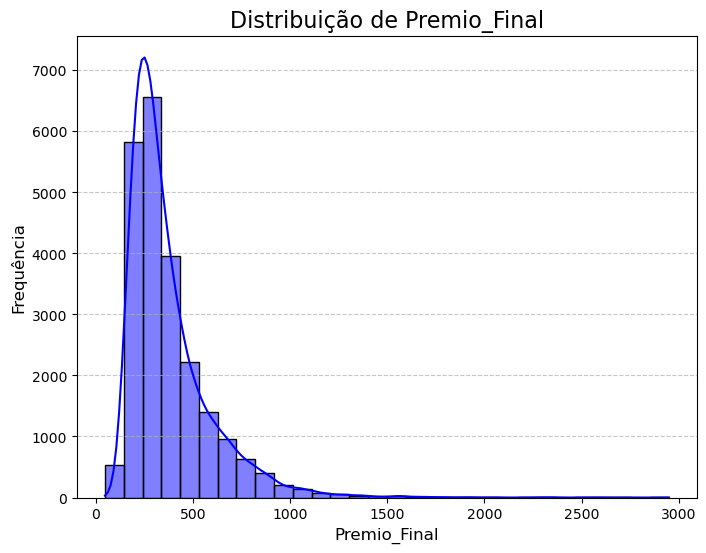

In [21]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Premio_Final'], kde=True, bins=30, color='blue')
plt.title('Distribuição de Premio_Final', fontsize=16)
plt.xlabel('Premio_Final', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

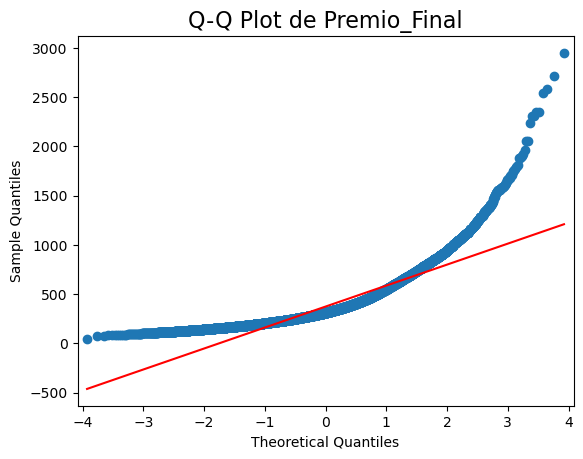

In [32]:
import statsmodels.api as sm

sm.qqplot(df['Premio_Final'], line='s')
plt.title('Q-Q Plot de Premio_Final', fontsize=16)
plt.show()

In [22]:
# Calcular Q1, Q3 e IQR
Q1 = df['Premio_Final'].quantile(0.25)
Q3 = df['Premio_Final'].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df[(df['Premio_Final'] < lower_bound) | (df['Premio_Final'] > upper_bound)]
print(f"Número de outliers: {len(outliers)}")

Número de outliers: 1281


Ha muitos valores atipicos no premio final quando naõ se renova o flag. isso pode indicar uma insatisfação com o valor cobrado ou dificuldades financeiras 

In [15]:
print(df.groupby('Flag_Renovou')['Premio_Final'].agg(['mean', 'median']))

                    mean  median
Flag_Renovou                    
0             370.981311  309.41
1             395.512654  334.85


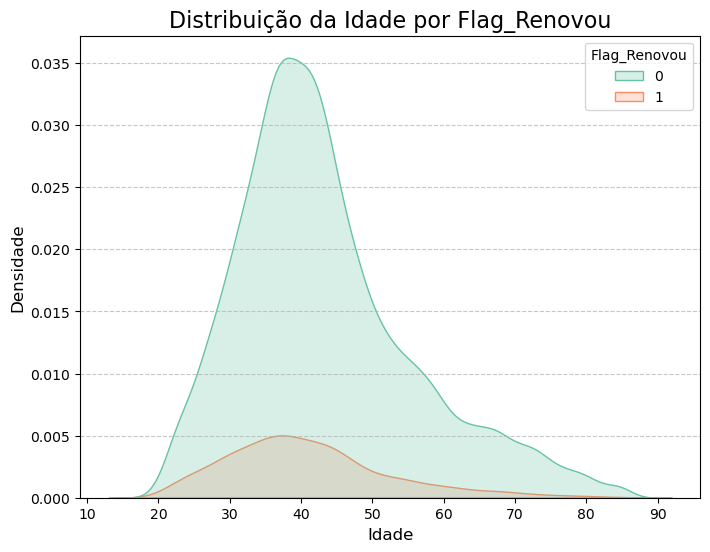

In [7]:
# Exemplo para 'Idade'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Idade', hue='Flag_Renovou', fill=True, palette='Set2')
plt.title('Distribuição da Idade por Flag_Renovou', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

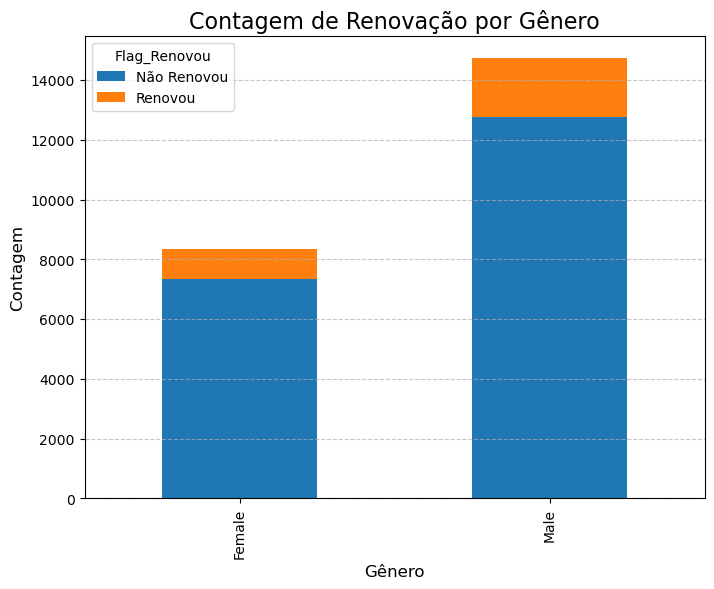

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Criando a tabela de contagem
crosstab_count = pd.crosstab(df['Genero'], df['Flag_Renovou'])

# Plotando o gráfico de barras
crosstab_count.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Contagem de Renovação por Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Flag_Renovou', labels=['Não Renovou', 'Renovou'])
plt.show()

In [16]:
# Tabela de contingência para Gênero e Flag_Renovou
contingency_table_genero = pd.crosstab(df['Genero'], df['Flag_Renovou'])

# Teste Chi-Square
chi2, p, _, _ = chi2_contingency(contingency_table_genero)
print(f"Chi-Square: {chi2}, p-value: {p}")

Chi-Square: 8.414137244468037, p-value: 0.0037231443237165794


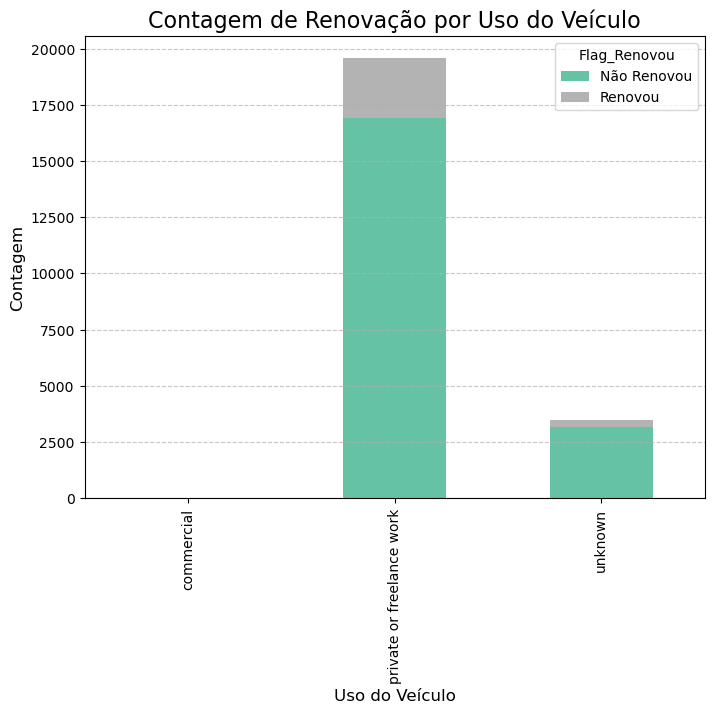

In [9]:
# Exemplo para 'Uso_Veiculo'
pd.crosstab(df['Uso_Veiculo'], df['Flag_Renovou']).plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Set2')
plt.title('Contagem de Renovação por Uso do Veículo', fontsize=16)
plt.xlabel('Uso do Veículo', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Flag_Renovou', labels=['Não Renovou', 'Renovou'])
plt.show()

C:\Users\tania\AppData\Local\Temp\ipykernel_4544\3692430542.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.


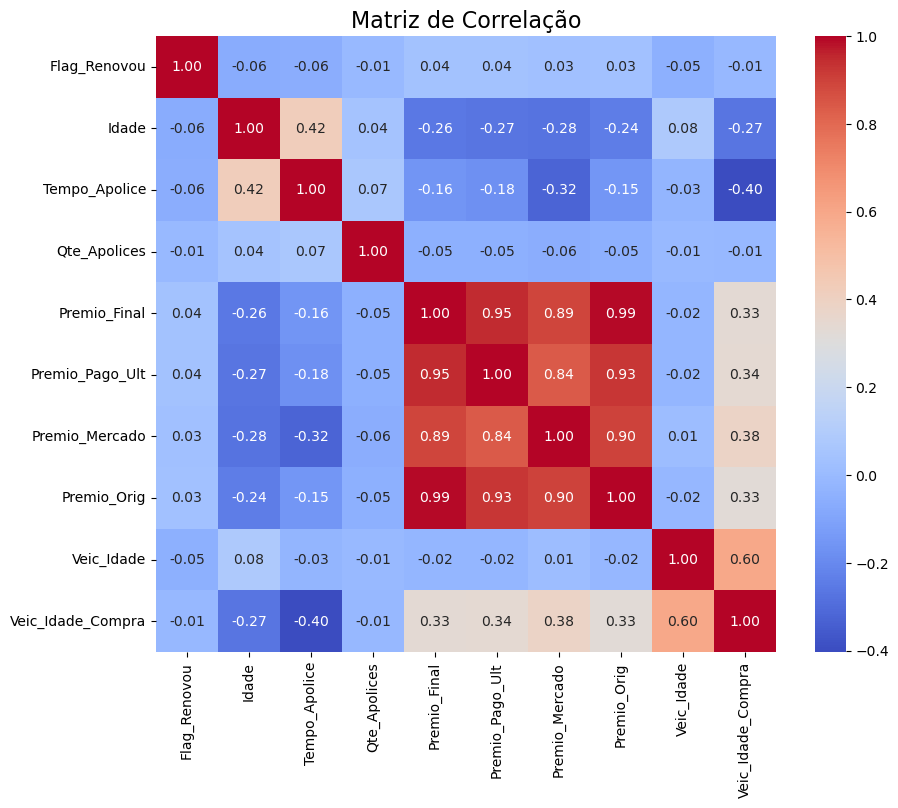

In [10]:
# Calcular a matriz de correlação
correlation_matrix = df.corr()

# Plotar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação', fontsize=16)
plt.show()

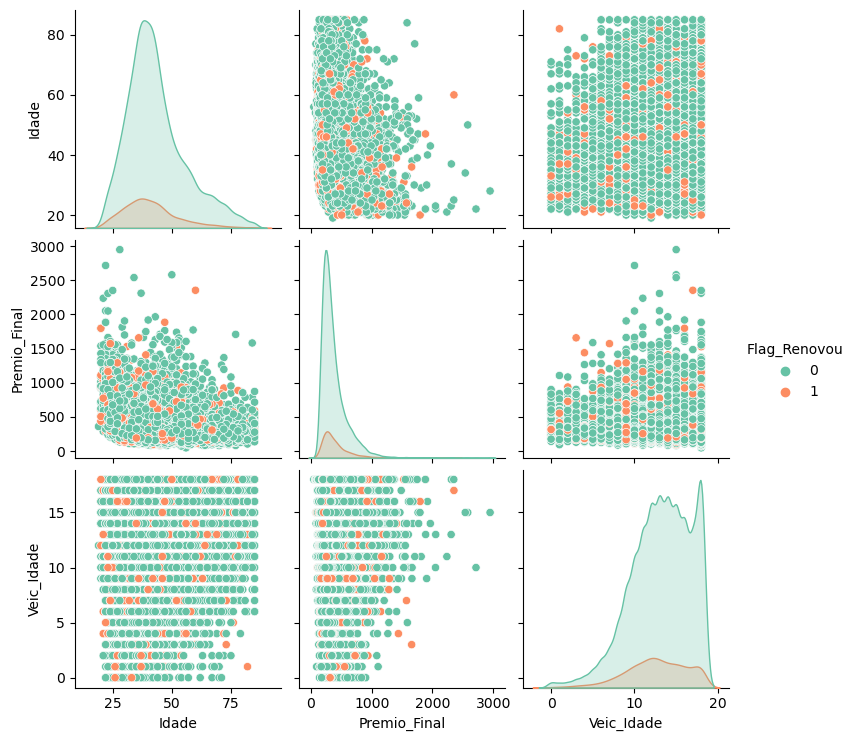

In [11]:
# Exemplo com algumas variáveis numéricas
sns.pairplot(df[['Idade', 'Premio_Final', 'Veic_Idade', 'Flag_Renovou']], hue='Flag_Renovou', palette='Set2')
plt.show()

### Analise Information Value 

In [3]:
df_rh_iv = aed.analise_iv(df,'Flag_Renovou')
df_rh_iv.get_lista_iv()

C:\Users\tania\Desktop\Git-Hub\Financial_Technology\Financial_Technology\aed.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Flag_Renovou,IV
Variavel,
Perfil_Risco,0.07
Tempo_Apolice,0.06
Idade,0.04
Veic_Regiao,0.03
Uso_Veiculo,0.03
Premio_Mercado,0.02
Veic_Idade,0.02
Premio_Pago_Ult,0.02
Premio_Qte_Parc,0.02


Com base nos fatores de risco identificados, aqui estão algumas sugestões de planos de ação:

a) Segmentação de Clientes e Personalização de Ofertas
Perfil_Risco: Desenvolver segmentos de clientes com base no perfil de risco e oferecer pacotes personalizados. Por exemplo, clientes de alto risco podem receber descontos ou benefícios adicionais para incentivá-los a renovar.

Idade: Criar campanhas específicas para diferentes faixas etárias. Por exemplo, oferecer descontos para jovens condutores ou pacotes especiais para idosos.

b) Retenção de Clientes de Longo Prazo
Tempo_Apolice: Implementar programas de fidelidade para clientes de longo prazo. Oferecer benefícios como descontos progressivos, serviços adicionais gratuitos (como assistência em viagem) ou recompensas por lealdade.

Premio_Pago_Ult: Revisar os prêmios pagos pelos clientes de longo prazo e oferecer ajustes personalizados para garantir que eles sintam que estão recebendo valor pelo que pagam.

c) Ajuste de Prêmios e Condições
Premio_Mercado: Realizar análises de mercado regularmente para garantir que os prêmios oferecidos sejam competitivos. Se necessário, ajustar os prêmios para clientes que estão em risco de migrar para a concorrência.

Veic_Idade: Oferecer descontos ou condições especiais para veículos mais antigos, que podem ter prêmios mais altos.

d) Melhoria na Comunicação e Engajamento
Veic_Regiao: Comunicar-se com clientes em regiões de alto risco sobre medidas de segurança adicionais que a empresa oferece, como rastreamento veicular ou assistência 24 horas.

Uso_Veiculo: Oferecer pacotes específicos para diferentes usos de veículos (por exemplo, pacotes para veículos comerciais que incluem cobertura para carga).

e) Análise de Satisfação e Feedback
Premio_Qte_Parc: Realizar pesquisas de satisfação com clientes que não renovaram para entender as razões por trás da decisão. Isso pode ajudar a identificar áreas de melhoria no produto ou serviço.

Diferenca_Perfil: Analisar se há uma discrepância entre o perfil de risco inicial e o perfil atual do cliente. Se houver, ajustar a apólice para refletir melhor o risco real.

f) Incentivos Financeiros e Promocionais
Qte_Apolices: Oferecer descontos ou benefícios para clientes que possuem múltiplas apólices com a empresa, incentivando a renovação de todas as apólices.

Premio_Final: Oferecer descontos ou bônus para clientes que renovam antes do vencimento da apólice.

g) Melhoria na Experiência do Cliente
Genero, Profissao, Veic_Garagem, Veic_Potencia: Embora esses fatores tenham um IV baixo, ainda podem ser relevantes em análises mais detalhadas. Por exemplo, oferecer serviços personalizados com base na profissão do cliente ou na potência do veículo pode melhorar a experiência geral e aumentar a retenção.

In [10]:
df["Uso_Veiculo"].unique

<bound method Series.unique of 0        private or freelance work
1        private or freelance work
2        private or freelance work
3        private or freelance work
4                          unknown
                   ...            
23055    private or freelance work
23056    private or freelance work
23057    private or freelance work
23058    private or freelance work
23059    private or freelance work
Name: Uso_Veiculo, Length: 23060, dtype: object>

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Previsões do modelo
y_pred = resultado.predict(df_modelo_l)
y_pred_class = (y_pred > 0.5).astype(int)  # Convertendo probabilidades em classes (0 ou 1)

# Matriz de Confusão
print("Matriz de Confusão:")
print(confusion_matrix(y, y_pred_class))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y, y_pred_class))

# AUC-ROC
auc_roc = roc_auc_score(y, y_pred)
print(f"\nAUC-ROC: {auc_roc:.4f}")

Matriz de Confusão:
[[20106     0]
 [ 2954     0]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     20106
           1       0.00      0.00      0.00      2954

    accuracy                           0.87     23060
   macro avg       0.44      0.50      0.47     23060
weighted avg       0.76      0.87      0.81     23060


AUC-ROC: 0.6003


C:\Users\tania\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\tania\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
C:\Users\tania\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [15]:
import pandas as pd
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Separando a variável resposta
y = df['Flag_Renovou']

# Removendo apenas a variável resposta e outras colunas irrelevantes
df2 = df.drop(columns=['Uso_Veiculo','Qte_Apolices','Flag_Renovou','Veic_Idade_Compra','Premio_Pago_Ult','Premio_Final','Premio_Qte_Parc','Diferenca_Perfil','Premio_Orig'])

# Agrupando categorias da variável Veic_Potencia
def agrupar_potencia(potencia):
    if potencia in ['Veic_Potencia_125-300 kW', 'Veic_Potencia_150 kW', 'Veic_Potencia_175 kW']:
        return 'Potencia_125-175 kW'
    elif potencia in ['Veic_Potencia_200 kW', 'Veic_Potencia_225 kW', 'Veic_Potencia_250 kW', 
                      'Veic_Potencia_275 kW', 'Veic_Potencia_300 kW']:
        return 'Potencia_200-300 kW'
    elif potencia in ['Veic_Potencia_25-50 kW', 'Veic_Potencia_75 kW']:
        return 'Potencia_25-75 kW'
    else:
        return 'Outros'

df2['Veic_Potencia'] = df2['Veic_Potencia'].apply(agrupar_potencia)

# Agrupando categorias da variável Veic_Regiao
def agrupar_regiao(regiao):
    if regiao in ['Veic_Regiao_Reg10', 'Veic_Regiao_Reg11', 'Veic_Regiao_Reg12', 
                  'Veic_Regiao_Reg13', 'Veic_Regiao_Reg14']:
        return 'Regiao_Grupo1'
    elif regiao in ['Veic_Regiao_Reg2', 'Veic_Regiao_Reg3', 'Veic_Regiao_Reg4', 'Veic_Regiao_Reg5']:
        return 'Regiao_Grupo2'
    elif regiao in ['Veic_Regiao_Reg6', 'Veic_Regiao_Reg7', 'Veic_Regiao_Reg8', 'Veic_Regiao_Reg9']:
        return 'Regiao_Grupo3'
    else:
        return 'Outros'

df2['Veic_Regiao'] = df2['Veic_Regiao'].apply(agrupar_regiao)

# Criando variáveis dummies e descartando a primeira categoria para evitar multicolinearidade
df_modelo_l2 = pd.get_dummies(df2, drop_first=True)

# Normalizando variáveis numéricas
scaler = StandardScaler()
numeric_cols = df_modelo_l2.select_dtypes(include=['int64', 'float64']).columns
df_modelo_l2[numeric_cols] = scaler.fit_transform(df_modelo_l2[numeric_cols])

# Balanceando os dados com SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(df_modelo_l2, y)

# Adicionando uma constante ao modelo (intercepto)
X_res = sm.add_constant(X_res)

# Criando o modelo de regressão logística usando statsmodels
modelo_l2 = sm.Logit(y_res, X_res)

# Ajustando o modelo
try:
    resultado = modelo_l2.fit(maxiter=200)  # Aumentando o número máximo de iterações
    print(resultado.summary())
except Exception as e:
    print(f"Erro ao ajustar o modelo: {e}")

Optimization terminated successfully.
         Current function value: 0.668086
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           Flag_Renovou   No. Observations:                40212
Model:                          Logit   Df Residuals:                    40196
Method:                           MLE   Df Model:                           15
Date:                Tue, 18 Feb 2025   Pseudo R-squ.:                 0.03616
Time:                        14:13:46   Log-Likelihood:                -26865.
converged:                       True   LL-Null:                       -27873.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.6597      0.042     15.535  

C:\Users\tania\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.


In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Previsões do modelo
y_pred = resultado.predict(df_modelo_l2)
y_pred_class = (y_pred > 0.5).astype(int)  # Convertendo probabilidades em classes (0 ou 1)

# Matriz de Confusão
print("Matriz de Confusão:")
print(confusion_matrix(y, y_pred_class))

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y, y_pred_class))

# AUC-ROC
auc_roc = roc_auc_score(y, y_pred)
print(f"\nAUC-ROC: {auc_roc:.4f}")

ValueError: shapes (23060,15) and (16,) not aligned: 15 (dim 1) != 16 (dim 0)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Treinar o modelo
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Avaliar o modelo
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Matriz de Confusão:
[[5349  702]
 [ 893 5120]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      6051
           1       0.88      0.85      0.87      6013

    accuracy                           0.87     12064
   macro avg       0.87      0.87      0.87     12064
weighted avg       0.87      0.87      0.87     12064



Distribuição das classes antes do oversampling:
0    12020
1     1816
Name: Flag_Renovou, dtype: int64

Distribuição das classes após o oversampling:
0    12020
1     9616
Name: Flag_Renovou, dtype: int64
[0]	validation_0-logloss:0.61325
[1]	validation_0-logloss:0.61042
[2]	validation_0-logloss:0.60795
[3]	validation_0-logloss:0.60594
[4]	validation_0-logloss:0.60510
[5]	validation_0-logloss:0.60396
[6]	validation_0-logloss:0.60250
[7]	validation_0-logloss:0.60093
[8]	validation_0-logloss:0.59994
[9]	validation_0-logloss:0.59915


C:\Users\tania\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
C:\Users\tania\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.


[10]	validation_0-logloss:0.59853
[11]	validation_0-logloss:0.59735
[12]	validation_0-logloss:0.59678
[13]	validation_0-logloss:0.59602
[14]	validation_0-logloss:0.59523
[15]	validation_0-logloss:0.59439
[16]	validation_0-logloss:0.59431
[17]	validation_0-logloss:0.59394
[18]	validation_0-logloss:0.59301
[19]	validation_0-logloss:0.59233
[20]	validation_0-logloss:0.59205
[21]	validation_0-logloss:0.59158
[22]	validation_0-logloss:0.59081
[23]	validation_0-logloss:0.59049
[24]	validation_0-logloss:0.59023
[25]	validation_0-logloss:0.58953
[26]	validation_0-logloss:0.58919
[27]	validation_0-logloss:0.58860
[28]	validation_0-logloss:0.58787
[29]	validation_0-logloss:0.58741
[30]	validation_0-logloss:0.58644
[31]	validation_0-logloss:0.58665
[32]	validation_0-logloss:0.58652
[33]	validation_0-logloss:0.58634
[34]	validation_0-logloss:0.58560
[35]	validation_0-logloss:0.58556
[36]	validation_0-logloss:0.58517
[37]	validation_0-logloss:0.58466
[38]	validation_0-logloss:0.58414
[39]	validatio

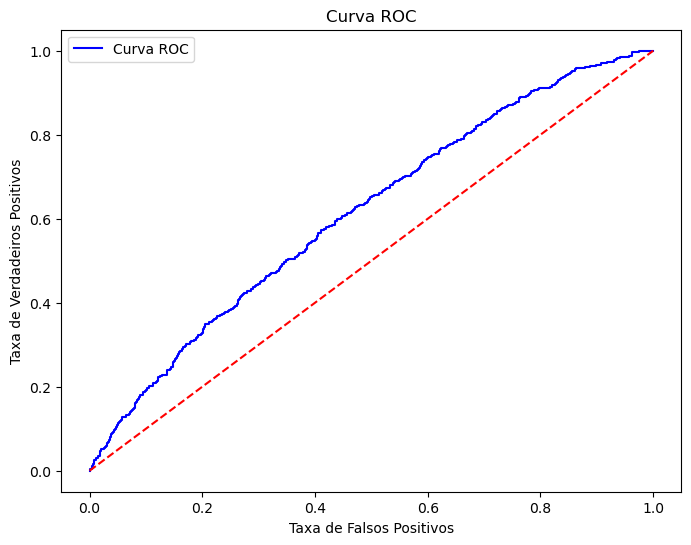

In [35]:
import xgboost as xgb
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, precision_score, f1_score
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import imblearn.over_sampling
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Supondo que você já tenha um DataFrame `df` com as variáveis explicativas e a variável target
# Exemplo:
df = pd.read_excel('base_Seguros.xlsx', sheet_name = 1)

# Target (variável resposta)
y = df['Flag_Renovou']

# Features (variáveis explicativas)
x = df.drop(columns=['Flag_Renovou'])

# Identifique as colunas categóricas no DataFrame
colunas_categoricas = x.select_dtypes(include=['object']).columns

# Aplicar OneHotEncoder nas colunas categóricas
if len(colunas_categoricas) > 0:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    x_encoded = pd.DataFrame(
        encoder.fit_transform(x[colunas_categoricas]),
        columns=encoder.get_feature_names_out(colunas_categoricas),
        index=x.index
    )
    x = pd.concat([x.drop(columns=colunas_categoricas), x_encoded], axis=1)

# Divisão inicial entre treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)

# Divisão do treino em treino e validação
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=50)

# Verifique a distribuição das classes antes do oversampling
print("Distribuição das classes antes do oversampling:")
print(y_train.value_counts())

# Aplicação de oversampling apenas na base de treino
rnd_over = imblearn.over_sampling.RandomOverSampler(sampling_strategy=0.8, random_state=42)
x_train_over, y_train_over = rnd_over.fit_resample(x_train, y_train)

# Verifique a distribuição das classes após o oversampling
print("\nDistribuição das classes após o oversampling:")
print(pd.Series(y_train_over).value_counts())

# Definição do modelo XGBoost
modelo = xgb.XGBClassifier(
    random_state=50,
    eval_metric='logloss',
    max_depth=3,              # Profundidade menor para evitar overfitting
    min_child_weight=5,       # Peso mínimo para as folhas
    gamma=0.2,                # Penalização para maior complexidade
    subsample=0.8,            # Usar 80% dos dados para cada árvore
    colsample_bytree=0.8,     # Usar 80% das features para cada árvore
    n_estimators=200,         # Número de árvores
    reg_alpha=0.1,            # Regularização L1
    reg_lambda=0.1,           # Regularização L2
    early_stopping_rounds=10, # Early stopping
    learning_rate=0.1         # Taxa de aprendizado
)

# Treinamento com early stopping
modelo.fit(
    x_train_over, y_train_over,
    eval_set=[(x_valid, y_valid)],
    verbose=True
)

# Avaliação do modelo
pred_train = modelo.predict_proba(x_train_over)[:, 1]
pred_valid = modelo.predict_proba(x_valid)[:, 1]
pred_test = modelo.predict_proba(x_test)[:, 1]

# Converter as probabilidades em predições binárias
pred_train_bin = (pred_train > 0.5).astype(int)
pred_valid_bin = (pred_valid > 0.5).astype(int)
pred_test_bin = (pred_test > 0.5).astype(int)

# Cálculo das métricas
resultados_finais = pd.DataFrame({
    "Recall em Treino": [recall_score(y_train_over, pred_train_bin)],
    "Recall em Valid": [recall_score(y_valid, pred_valid_bin)],
    "Recall em Teste": [recall_score(y_test, pred_test_bin)],
    "AUC em Treino": [roc_auc_score(y_train_over, pred_train)],
    "AUC em Valid": [roc_auc_score(y_valid, pred_valid)],
    "AUC em Teste": [roc_auc_score(y_test, pred_test)],
    "Precisão em Treino": [precision_score(y_train_over, pred_train_bin)],
    "Precisão em Valid": [precision_score(y_valid, pred_valid_bin)],
    "Precisão em Teste": [precision_score(y_test, pred_test_bin)],
    "F1-Score em Treino": [f1_score(y_train_over, pred_train_bin)],
    "F1-Score em Valid": [f1_score(y_valid, pred_valid_bin)],
    "F1-Score em Teste": [f1_score(y_test, pred_test_bin)]
})

print("\nResultados Finais:")
print(resultados_finais)

# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, pred_test_bin)
print("\nMatriz de Confusão:")
print(conf_matrix)

# Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, pred_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Curva ROC', color='b')
plt.plot([0, 1], [0, 1], linestyle='--', color='r')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo de sobrevivencia 

A curva de Kaplan-Meier ajuda a entender a probabilidade de um cliente 
continuar com o seguro ao longo do tempo 

Pdemos segmentar ela por grupos, por exemplo faixa etária 

Existe tambem um teste estatistico para comparação dos grupos . 
Teste de Log-Rank


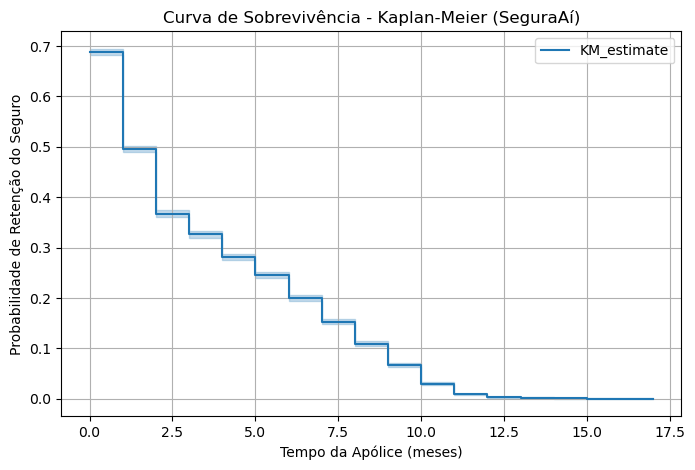

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Carregar a base de dados
df = pd.read_excel('base_Seguros.xlsx', sheet_name=1)

# Ajustar os nomes das colunas para Kaplan-Meier
df['tempo'] = df['Tempo_Apolice']  # Tempo até o cancelamento ou censura
df['cancelou'] = 1 - df['Flag_Renovou']  # Inverter: 1 = cancelou, 0 = renovou

# Criar o modelo Kaplan-Meier
kmf = KaplanMeierFitter()

# Ajustar o modelo aos dados
kmf.fit(durations=df['tempo'], event_observed=df['cancelou'])

# Plotar a curva de sobrevivência
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Curva de Sobrevivência - Kaplan-Meier (SeguraAí)")
plt.xlabel("Tempo da Apólice (meses)")
plt.ylabel("Probabilidade de Retenção do Seguro")
plt.grid(True)
plt.show()

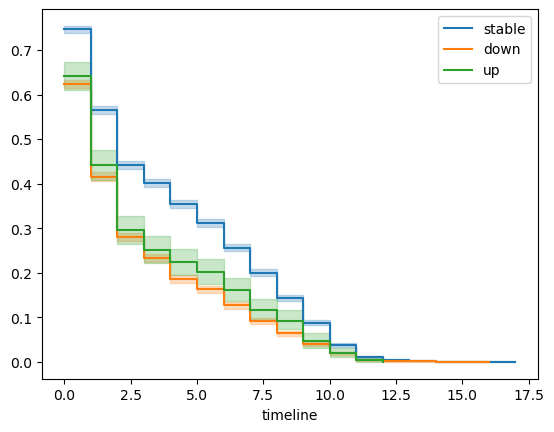

In [31]:
for grupo in df['Perfil_Risco'].unique():
    kmf.fit(df[df['Perfil_Risco'] == grupo]['tempo'], df[df['Perfil_Risco'] == grupo]['cancelou'], label=grupo)
    kmf.plot_survival_function()

In [ ]:
from lifelines.statistics import logrank_test

# Definição correta das colunas
time_col = "Tempo_Apolice"  # Nome correto do tempo
event_col = "Flag_Renovou"  # Indica se o seguro foi renovado (evento)

# Função para realizar o teste log-rank
def realizar_logrank(grupo1, grupo2):
    time_1 = grupo1[time_col]
    event_1 = grupo1[event_col]
    time_2 = grupo2[time_col]
    event_2 = grupo2[event_col]
    
    resultado = logrank_test(time_1, time_2, event_observed_A=event_1, event_observed_B=event_2)
    return resultado.summary

# Realizando os testes entre os grupos de risco
resultados_stable_up = realizar_logrank(group_stable, group_up)
resultados_stable_down = realizar_logrank(group_stable, group_down)
resultados_up_down = realizar_logrank(group_up, group_down)

# Exibindo os resultados
print("Stable vs Up:\n", resultados_stable_up)
print("Stable vs Down:\n", resultados_stable_down)
print("Up vs Down:\n", resultados_up_down)



In [8]:
df2 = df[df['Flag_Renovou'] == 0]

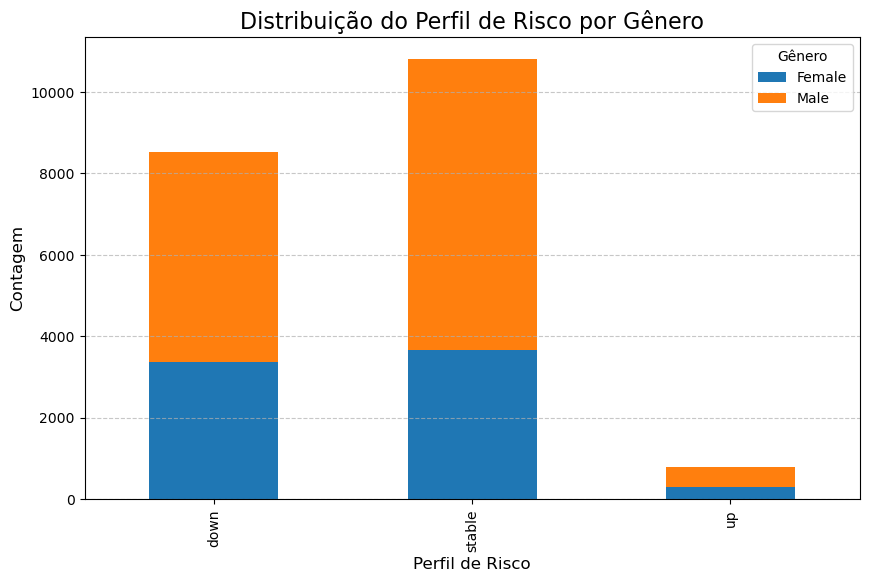

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Criando a tabela de contingência
crosstab_risco_genero = pd.crosstab(df2['Perfil_Risco'], df['Genero'])

# Plotando o gráfico de barras empilhadas
crosstab_risco_genero.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribuição do Perfil de Risco por Gênero', fontsize=16)
plt.xlabel('Perfil de Risco', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gênero')
plt.show()

In [ ]:

arvore_decisao = modelo_Renovação.tree_

# Acessar os nós da árvore e seus valores



for no in range(arvore_decisao.node_count):
    if arvore_decisao.feature[no] != -2:  # Verifica se não é um nó folha
        print(f"Nó {no}: Feature {arvore_decisao.feature[no]}, Valor de Limite {arvore_decisao.threshold[no]}")
    else:
        print(f"Nó {no}: Folha, Classe {arvore_decisao.value[no]}")

##### Codificação das variaveis categoricas

In [57]:
# Função para extrair o valor numérico mínimo de cada categoria
def extrair_valor_minimo(potencia):
    if isinstance(potencia, str):  # Verifica se é string
        try:
            # Extrair o primeiro número da faixa (ex.: '25-50 kW' -> 25)
            return int(potencia.split('-')[0].split()[0])
        except ValueError:
            return None  # Caso não seja possível extrair um número
    else:
        return potencia  # Se já for numérico

# Criar uma lista de tuplas (categoria, valor_mínimo)
categorias_unicas = df['Veic_Potencia'].unique()
categorias_com_valores = [(cat, extrair_valor_minimo(cat)) for cat in categorias_unicas]

# Ordenar as categorias pelo valor mínimo
categorias_ordenadas = [cat for cat, _ in sorted(categorias_com_valores, key=lambda x: x[1])]

print("Categorias ordenadas por potência:")
print(categorias_ordenadas)

Categorias ordenadas por potência:
['25-50 kW', '75 kW', '100 kW', '125-300 kW', '150 kW', '175 kW', '200 kW', '225 kW', '250 kW', '275 kW', '300 kW']


In [58]:
from sklearn.preprocessing import OrdinalEncoder

# Aplicar Ordinal Encoding com a ordem definida
ordinal_encoder = OrdinalEncoder(categories=[categorias_ordenadas])
df['Veic_Potencia_encoded'] = ordinal_encoder.fit_transform(df[['Veic_Potencia']])

# Visualizar o resultado
print(df[['Veic_Potencia', 'Veic_Potencia_encoded']].head())

  Veic_Potencia  Veic_Potencia_encoded
0        225 kW                    7.0
1        100 kW                    2.0
2        100 kW                    2.0
3         75 kW                    1.0
4         75 kW                    1.0


In [59]:
# One-Hot Encoding para variáveis nominais
df_encoded = pd.get_dummies(df_cleaned, columns=['Perfil_Risco', 'Genero', 'Profissao', 'Uso_Veiculo', 'Veic_Garagem', 'Veic_Regiao'], drop_first=True)